# Welcome to the OHDSI tutorial for Five Safes TES!
## Contents
1. [Introduction](#1.-Introduction)
2. [Workbench](#2.-Workbench)
3. [Incidence and prevalence](#3.-Incidence-and-Prevalence)
    1. [Cohort discovery](#3.1-Cohort-discovery)
    2. [Design and submit your analysis](#3.2-Design-and-submit-your-analysis)
    3. [Collect results](#3.3-Collect-your-results)
    4. [Visualise results](#3.4-Visualise-results)
    5. [I thought this was federated?](#3.5-I-thought-this-was-federated?)

## 1. Introduction

This Jupyter notebook is a tutorial for running analysis through Five Safes TES (5S-TES) using a python package, the 5S-TES Workbench, to send tasks to a 5S-TES submission layer and collect your results.
The example uses Darwin EU libraries to analyse OMOP data.

By the end of this notebook, you will have:
1. Connected to 5S-TES with the workbench
2. Defined an analysis using a Darwin EU library
3. Submitted it to the TES server as a TES message
4. Fetched the outputs of your analysis and visualised them.

This notebook has some "cells" which is a group of executable Python code. To run the code/cell, you can simply click on the cell and press the play button or pressing `Shift+Enter`.

Before each cell, we will provide a description of the task and the expected outputs. The full guide on how to run Workbench is available [here](https://docs.federated-analytics.ac.uk/tutorials/submit-to-5s-tes/workbench).

Start by loading the code supporting this notebook. Select the cell below and run it.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings

from i_p_utils import load_5s_tes_incidence_result, plot_incidence_results, combine_incidence_results, plot_jittered
from omop_metadata_utils import DistributionCodesets
from ui import CodesetDisplay, IncidencePrevalenceForm, WorkbenchForm

warnings.filterwarnings('ignore')
print("Imported libraries, keep going!")

Imported libraries, keep going!


## 2. Workbench

The 5S-TES Workbench is a Python library that stores the configuration necessary to connect to 5S-TES, and can be used to submit tasks as TES messages and collect your results.

To use the Workbench, you need to supply some credentials.
For this workshop, we have pre-defined some of the connection parameters.

<details>
    <summary>Configuration details</summary>


- `project`: The name of the project you are working on, e.g. "OHDSIDemo".
- `tres`: The TREs you want to run the analysis on, e.g. "Nottingham TRE 01" and "Nottingham TRE 02".
- `tes_base_url`: The base URL of the TES server. For 5S-TES, this is the Submission layer API endpoint.
- `keycloak_url`: The URL of the Keycloak server.
- `client_id` and `client_secret`: The client ID and client secret for the OIDC Keycloak server.
- `username` and `password`: Your username and password for 5S-TES Submission layer.
</details>

If you run the cell below, you will be shown a form which handles initialisation of the workbench for you; you only need to enter your username and password, then click the button to check that you can connect.

In [2]:
wb_form = WorkbenchForm()

wb_form.display()

## 3. Incidence and Prevalence

The [IncidencePrevalence library](https://darwin-eu.github.io/IncidencePrevalence/) from [Darwin EU](https://www.darwin-eu.org/index.php) estimates incidence or prevalence of an outcome on synthetic data in OMOP databases in two TREs (Nottingham TRE 01 and Nottingham TRE 02).

To make sure everyone can complete the analysis during the workshop, a simplified analysis has been presented, but more complex analysis can be defined (see [the toolkit](https://github.com/Health-Informatics-UoN/omop-r-toolkit/#incidence-and-prevalence) for more information).

<details>
    <summary>How the analysis workflow runs</summary>


This analysis runs multiple R scripts under the hood.

1. The first script defines an outcome cohort using [CDMConnector](https://darwin-eu.github.io/CDMConnector/reference/generateConceptCohortSet.html) (thanks again Darwin EU!)
2. The second script defines a denominator cohort, which for this analysis is everyone aged 0 to 150 observed since 1990, and estimates incidence for the outcome.
3. Cleans up the cohort tables to be polite    
</details>

### 3.1 Cohort discovery
Before you can estimate Incidence or prevalence, you need to define your outcome.
Running the cell below will show you a bar chart of the number of times different concepts occur in the synthetic data.
Try searching for a condition you're interested in to find concepts represented in the dataset.

In [ ]:
codesets = DistributionCodesets(
    {
        "Nottingham TRE 01": "metadata/1242/output.json",
        "Nottingham TRE 02": "metadata/1243/output.json",
    }
)

codeset_display = CodesetDisplay(codesets)
codeset_display.display()

### 3.2 Design and submit your analysis

Running the cell beneath this text will present you with a form to design your incidence analysis.
The form has text boxes for the details of your analysis.

1. Researcher name - your name
2. Outcome cohort name - A name for your outcome cohort. This and the denominator cohort name need to be in `snake_case`, e.g. "skin_cancer_test_denominator" and "skin_cancer_test"
3. Concept sets - a named list of concept IDs that together define a cohort, e.g. `{"neoplasm": [139750]}`. Use the [cohort discovery](#3.1-Cohort-discovery) section above to find some
4. Denominator cohort name - A name for your denominator cohort, using `snake_case`

To finish sending your analysis, after filling in the form, click the button "Submit" once to build the TES task and submit it to the TES server.
Note: Each time you click "Submit", it will build a new TES task and submit it to the 5S-TES submission layer, so please don't run it over and over!

You can check the status of your task on [the submission layer](https://5s-tes.federated-research.com/Submission/GetAllSubmissions).
It will probably take about 5-7 minutes to run, then you have to wait for egress before the outputs is available, so now might be a good time to see if we've provided refreshments!

In [3]:
wb = wb_form.validate()
task_form = IncidencePrevalenceForm(wb=wb)
task_form.display()

INFO | Template registered: 'hello_world'
INFO | Template registered: 'custom'
INFO | Template registered: 'simple_sql'
INFO | Template registered: 'bunny'
INFO | Template registered: 'analysis'
INFO | Validation successful
INFO | Config: project='OHDSIDemo' tes_base_url='https://api.5s-tes.federated-research.com/' tres=['Nottingham TRE 01', 'Nottingham TRE 02']
INFO | Auth mode: AuthMode.CREDENTIALS


### 3.3 Collect your results
5S-TES tasks finish by writing results to a file, which you can then collect.
Once the outputs of your task are approved by TRE's Egress officer, you can retrieve them by running the following cell.

By default, without any parameters, function `fetch_outputs` will try fetching the outputs related to the latest task, which you just submitted, from all targeted TREs and save them in the `output` directory next to this notebook.

You can also fetch outputs from a specific task by passing the `task_id` parameter to the function. For example, to fetch the outputs from task with `task_id = 1823`, you can run: `wb.fetch_outputs(task_id=1823)`

In [4]:
incidence_output = wb.fetch_outputs(task_id=3126)

INFO | Fetching Keycloak ID token for STS exchange...
INFO | Requesting Keycloak token from https://drs-core-identity.azurewebsites.net/realms/Dare-Control/protocol/openid-connect/token
INFO | Keycloak token fetched successfully
INFO | Exchanging bearer token for MinIO credentials via STS (https://api.s3.5s-tes.federated-research.com)
INFO | MinIO client initialized (endpoint=https://api.s3.5s-tes.federated-research.com, secure=True)
INFO | Child task info: 3127, TRE: Nottingham TRE 01, status: Completed
INFO | Found 1 result object(s) for task 3127
INFO | Downloading result object: 3127/incidence.csv
INFO | Downloaded 3127/incidence.csv -> /Users/jamesmitchell-white/Documents/GitHub/5s-TES-notebooks/Darwin-EU/output/Nottingham TRE 01/3127/incidence.csv
INFO | Child task info: 3128, TRE: Nottingham TRE 02, status: Completed
INFO | Found 1 result object(s) for task 3128
INFO | Downloading result object: 3128/incidence.csv
INFO | Downloaded 3128/incidence.csv -> /Users/jamesmitchell-whit

### 3.4 Visualise results
The outputs of the analysis are comma-separated value (csv) files for tables in the [omopgenerics](https://darwin-eu.github.io/omopgenerics) `summarised_result` format.
This is a standard way of representing results in the Darwin EU ecosystem, so the files can be analysed in R using their libraries.
For this workshop, we have some utilities for these files in Python, but if you want to carry out some analysis we don't support here, you can still use the R libraries on the files.

Running the cell below will:
1. Read the outputs into the notebook and wrangle them into the right shape for analysis
2. Plot the outputs from each TRE as a scatter plot with bars to show the 95% confidence intervals.

The synthetic data probably don't have very high incidence for any given condition, so don't expect anything dramatic!

In [5]:
# Read the outputs into the notebook and wrangle them into the right shape for analysis
incidence_results = load_5s_tes_incidence_result(incidence_output)

# Plot the results
plot_incidence_results(incidence_results)

### 3.5 I thought this was federated?
So far, we have looked at the results in isolation.
As we have used the same cohort definition when querying both TREs, it might make sense to analyse the results as if they were one big cohort.
The results tables contain the information required to combine the results in this way.
Run the cell below to combine the datasets.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


<Axes: xlabel='Date', ylabel='Incidence (100,000 person-years)'>

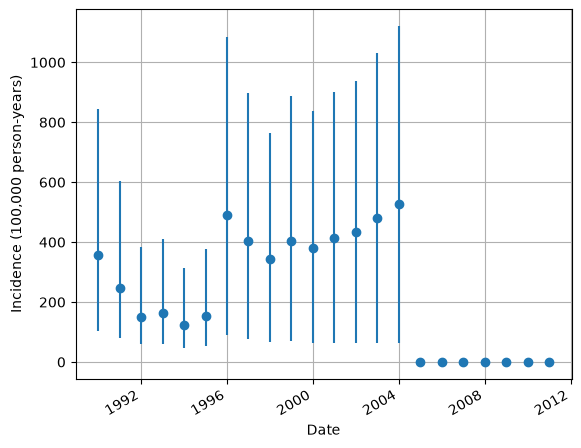

In [9]:
overall_incidence_result = combine_incidence_results(list(incidence_results.values()))

overall_incidence_result.plot_incidence()

We can plot the combined results and compare them with the individual TREs.

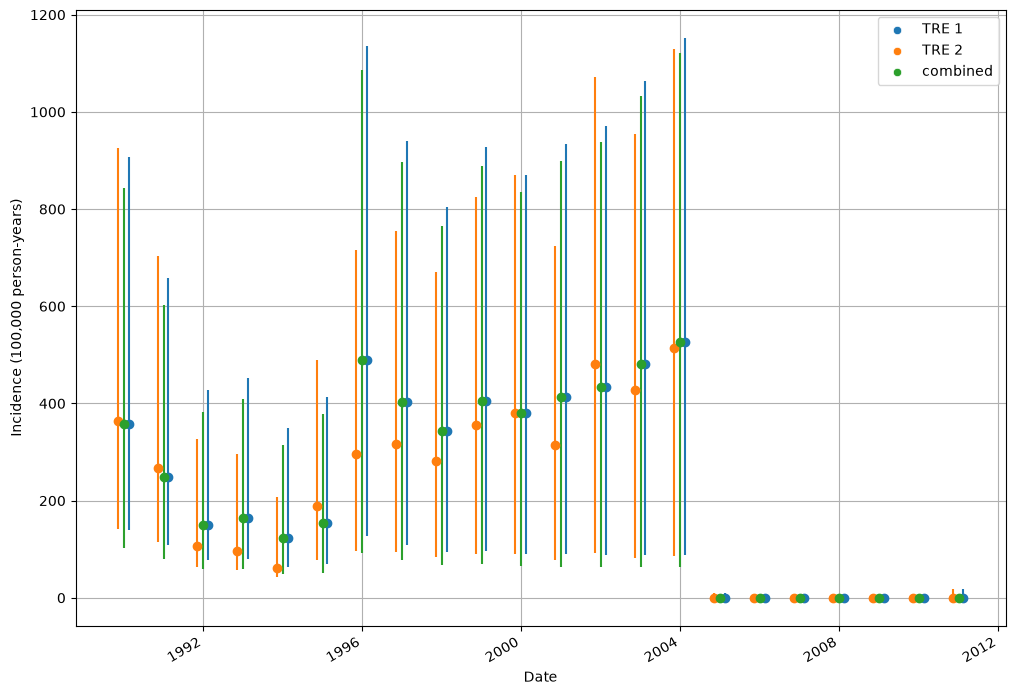

In [10]:
plot, ax = plt.subplots(figsize=(12, 8))

plot_jittered(incidence_results["Nottingham TRE 01"], ax=ax)
plot_jittered(incidence_results["Nottingham TRE 02"], offset_weeks=-8, ax=ax)
overall_incidence_result.plot_incidence(axes=ax)

ax.legend(["TRE 1", "TRE 2", "combined"])

plt.show()

### What next?
By running this example, you have learned how to use 5S-TES with the Workbench, congratulations!

If you want to learn more, check out the [workbench documentation](https://docs.federated-analytics.ac.uk/tutorials/submit-to-5s-tes/workbench), [other notebooks](https://github.com/Health-Informatics-UoN/5s-TES-notebooks/), and [our packages](https://github.com/Health-Informatics-UoN/omop-r-toolkit/) using the Darwin-EU tools.